# Pipeline vs Baseline Experiment

In [66]:
import sys
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

BASELINE_DIR = REPO_ROOT / "baseline"
if str(BASELINE_DIR) not in sys.path:
    sys.path.insert(0, str(BASELINE_DIR))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = REPO_ROOT / "database" / "training_data.json"
EXPERIMENT_DIR = REPO_ROOT / "experiments"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"CUDA available: {torch.cuda.is_available()}")

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json
CUDA available: True


In [67]:
import logging
from datetime import datetime

from logger import configure_logging

TRACE_LOG_PATH = EXPERIMENT_DIR / f"experimentation_pipeline_vs_baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
configure_logging(
    level="INFO",
    log_file=str(TRACE_LOG_PATH),
    enable_console=True,
    enable_file=True,
)

exp_logger = logging.getLogger("experimentation_pipeline_vs_baseline")
exp_logger.info("Trace logging initialized")
print(f"Trace log file: {TRACE_LOG_PATH}")

2026-03-24 11:19:25,993 - experimentation_pipeline_vs_baseline - INFO - Trace logging initialized
Trace log file: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/experimentation_pipeline_vs_baseline_20260324_111925.log


In [ ]:
TARGET = {
    "dbaasp_id": "DBAASPS_373",
    "sequence": "KLFKRWKHLFR",
    "length": 11,
    "smiles": "CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O",
    "ph": None,
    "molecular_weight": 1558.9480000000003,
    "logp": -0.992100000000006,
    "net_charge": 5.0,
    "isoelectric_point": 12.18,
    "hydrophobicity": 1.05,
    "cathionicity": 6,
    "target_groups": ["Gram+"],
    "complexity": "Monomer"
}

SHARED_MAX_LEN = 14
SHARED_BATCH_SIZE = 32
SHARED_EPOCHS = 100
SHARED_LATENT_DIM = 32

# Tuned pipeline hyperparameters (from pipeline_experimentations reference setup).
PIPELINE_LATENT_DIM = 64
PIPELINE_HIDDEN_DIM = 512
PIPELINE_EPOCHS = 100
PIPELINE_BATCH_SIZE = 64
PIPELINE_LR = 0.05
PIPELINE_KL_ANNEAL_EPOCHS = 40

NB_ITERATIONS = 50
NB_PEPTIDES = 100
TOP_K = 10
BASELINE_NUM_SAMPLES = 10

print(TARGET)
print(
    f"Pipeline tuned config -> latent={PIPELINE_LATENT_DIM}, hidden={PIPELINE_HIDDEN_DIM}, "
    f"epochs={PIPELINE_EPOCHS}, batch={PIPELINE_BATCH_SIZE}, lr={PIPELINE_LR}, kl_anneal={PIPELINE_KL_ANNEAL_EPOCHS}"
)

{'dbaasp_id': 'DBAASPS_373', 'sequence': 'KLFKRWKHLFR', 'length': 11, 'smiles': 'CC(C)C[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCN=C(N)N)C(=O)O', 'ph': None, 'molecular_weight': 1558.9480000000003, 'logp': -0.992100000000006, 'net_charge': 5.0, 'isoelectric_point': 12.18, 'hydrophobicity': 1.05, 'cathionicity': 6, 'target_groups': ['Gram+'], 'complexity': 'Monomer'}
Pipeline tuned config -> latent=64, hidden=512, epochs=120, batch=64, lr=0.05, kl_anneal=40


In [69]:
from training import train_model
from inference import generate_peptides

baseline_model_path = EXPERIMENT_DIR / "baseline_cvae_model.pth"
baseline_scaler_path = EXPERIMENT_DIR / "baseline_scaler.pkl"

baseline_model, _ = train_model(
    dataset_file=str(DATA_PATH),
    scaler_path=str(baseline_scaler_path),
    batch_size=SHARED_BATCH_SIZE,
    max_len=SHARED_MAX_LEN,
    epochs=SHARED_EPOCHS,
    latent_dim=SHARED_LATENT_DIM,
    model_path=str(baseline_model_path),
)

with open(baseline_scaler_path, "rb") as f:
    baseline_scaler = pickle.load(f)

baseline_target = [
    TARGET["length"],
    7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    TARGET["molecular_weight"],
    TARGET["logp"],
    TARGET["net_charge"],
    TARGET["isoelectric_point"],
    TARGET["hydrophobicity"],
    TARGET["cathionicity"],
]

baseline_sequences = generate_peptides(
    model=baseline_model,
    scaler=baseline_scaler,
    num_samples=BASELINE_NUM_SAMPLES,
    properties=baseline_target,
    temperature=0.9,
    top_k=5,
)

Using device: cuda
Scaler saved to /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scaler.pkl
Epoch [1/100] | Beta: 0.00 | Train Loss: 21.4799 | Train Recon: 21.4799 | Train KL: 66.7116 | Val Loss: 18.3806 | Val Recon: 18.3806 | Val KL: 108.8033
Epoch [5/100] | Beta: 0.08 | Train Loss: 13.9652 | Train Recon: 12.3938 | Train KL: 19.6430 | Val Loss: 13.4713 | Val Recon: 11.9304 | Val KL: 19.2605
Epoch [10/100] | Beta: 0.18 | Train Loss: 11.5829 | Train Recon: 8.9925 | Train KL: 14.3912 | Val Loss: 11.8423 | Val Recon: 9.3397 | Val KL: 13.9030
Epoch [15/100] | Beta: 0.28 | Train Loss: 10.7538 | Train Recon: 7.5165 | Train KL: 11.5619 | Val Loss: 11.6593 | Val Recon: 8.5647 | Val KL: 11.0521
Epoch [20/100] | Beta: 0.38 | Train Loss: 10.7060 | Train Recon: 7.1009 | Train KL: 9.4871 | Val Loss: 11.9754 | Val Recon: 8.4172 | Val KL: 9.3638
Epoch [25/100] | Beta: 0.48 | Train Loss: 10.7938 | Train Recon: 6.9396 | Train KL: 8.0294 | Val Loss: 12.0935 | Val Recon

In [70]:
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator

AA = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21


def encode_one_hot_with_pad(sequences, max_len):
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x


def build_condition_tensor(dataframe, model):
    cond = torch.zeros(len(dataframe), model.condition_dim, dtype=torch.float32)
    cond[:, 0] = torch.tensor(dataframe["length"].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe["molecular_weight"].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe["net_charge"].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe["isoelectric_point"].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe["hydrophobicity"].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe["cathionicity"].values, dtype=torch.float32)
    cond[:, 6] = 0.5
    cond[:, 7] = torch.tensor(dataframe["logp"].values, dtype=torch.float32)
    cond[:, 8] = 0.0
    cond[:, 9] = 5.0
    cond[:, 10] = 5.0
    cond[:, 11] = 100.0
    return cond


loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        "sequence",
        "length",
        "ph",
        "molecular_weight",
        "logp",
        "net_charge",
        "isoelectric_point",
        "hydrophobicity",
        "cathionicity",
    ],
    fillna_defaults={
        "length": 10,
        "ph": 7.0,
        "molecular_weight": 1500.0,
        "logp": 0.0,
        "net_charge": 0.0,
        "isoelectric_point": 7.0,
        "hydrophobicity": 0.0,
        "cathionicity": 0.0,
    },
    normalize_sequence=True,
    sequence_column="sequence",
    keep_standard_amino_acids_only=True,
)

pipeline_df = loader.get_data().copy()

pipeline_cvae = CVAEGenerator(
    max_len=SHARED_MAX_LEN,
    latent_dim=PIPELINE_LATENT_DIM,
    hidden_dim=PIPELINE_HIDDEN_DIM,
    condition_dim=32,
)

pipeline_model_path = EXPERIMENT_DIR / (
    f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
)

x = encode_one_hot_with_pad(pipeline_df["sequence"].tolist(), max_len=SHARED_MAX_LEN)
conditions = build_condition_tensor(pipeline_df, pipeline_cvae)
lengths = torch.tensor(pipeline_df["length"].astype(int).values, dtype=torch.long)

x = x.to(pipeline_cvae.device)
conditions = conditions.to(pipeline_cvae.device)
lengths = lengths.to(pipeline_cvae.device)

if pipeline_model_path.exists():
    pipeline_cvae.load_model(str(pipeline_model_path))
else:
    pipeline_cvae.train_model(
        data=x,
        conditions=conditions,
        lengths=lengths,
        epochs=PIPELINE_EPOCHS,
        batch_size=PIPELINE_BATCH_SIZE,
        lr=PIPELINE_LR,
        kl_anneal_epochs=PIPELINE_KL_ANNEAL_EPOCHS,
    )
    pipeline_cvae.save_model(str(pipeline_model_path))

print(f"Using pipeline model path: {pipeline_model_path.name}")

2026-03-24 11:20:10,501 - peptide_pipeline.dataloader - INFO - DataLoader initialized.
2026-03-24 11:20:10,540 - peptide_pipeline.dataloader - INFO - Data loaded successfully from /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/database/training_data.json. Total records: 4410
2026-03-24 11:20:10,540 - peptide_pipeline.dataloader - INFO - Data retrieval successful.
Using pipeline model path: pipeline_cvae_model_lat64_hid512_ep120_bs64.pth


In [71]:
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2
from peptide_pipeline.biologist.base import BaseBiologist


class FallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide):
        self.reference = reference_peptide

    def score_peptides(self, peptides):
        scores = []
        ref_set = set(self.reference)
        for p in peptides:
            common = len(ref_set.intersection(set(p)))
            scores.append(common / max(len(set(self.reference)), 1))
        return scores


chemist_config = ChemistConfig(
    ph=7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
    length=RangeTarget(min=8.0, max=14.0, target=float(TARGET["length"]), weight=1.0),
    molecular_weight=RangeTarget(min=1200.0, max=2000.0, target=float(TARGET["molecular_weight"]), weight=1.0),
    logp=RangeTarget(min=-3.0, max=3.0, target=float(TARGET["logp"]), weight=1.0),
    net_charge=RangeTarget(min=2.0, max=8.0, target=float(TARGET["net_charge"]), weight=1.0),
    isoelectric_point=RangeTarget(min=9.0, max=14.0, target=float(TARGET["isoelectric_point"]), weight=1.0),
    hydrophobicity=RangeTarget(min=-2.0, max=3.0, target=float(TARGET["hydrophobicity"]), weight=1.0),
)

chemist = ChemistAgent(config=chemist_config)

try:
    biologist = ESMBiologistGlobalL2(
        reference_peptide=TARGET["sequence"],
        batch_size=16,
        score_temperature=50.0,
    )
except Exception as e:
    print(f"Falling back to lightweight biologist: {e}")
    biologist = FallbackBiologist(reference_peptide=TARGET["sequence"])

orchestrator = Orchestrator(generator=pipeline_cvae, chemist=chemist, biologist=biologist)
pipeline_results = orchestrator.run(
    nb_iterations=NB_ITERATIONS,
    nb_peptides=NB_PEPTIDES,
    top_k=TOP_K,
    exploration_rate=0.15,
    initial_peptide=TARGET["sequence"],
    final_target={
        "length": TARGET["length"],
        "molecular_weight": TARGET["molecular_weight"],
        "logp": TARGET["logp"],
        "net_charge": TARGET["net_charge"],
        "isoelectric_point": TARGET["isoelectric_point"],
        "hydrophobicity": TARGET["hydrophobicity"],
        "cathionicity": TARGET["cathionicity"],
    },
)

2026-03-24 11:20:11,085 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:20:11,105 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 11:20:11,223 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:20:11,242 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 11:20:11,356 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 11:2

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1354.40it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2026-03-24 11:20:11,865 - peptide_pipeline.orchestrator - INFO - Pipeline start: 50 iterations, 300 peptides/iteration, exploration_rate=0.15, top_k=10
2026-03-24 11:20:11,866 - peptide_pipeline.orchestrator - INFO - Iteration 1: initial_peptide is provided ('KLFKRWKHLFR') but generation is driven by final_target constraints only.
2026-03-24 11:20:12,247 - peptide_pipeline.orchestrator - INFO - Iteration 1: mode=target_only, generated=300, in_limits=1, off_limits=299, best_combined=0.8315, global_unique=1


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


2026-03-24 11:20:12,631 - peptide_pipeline.orchestrator - INFO - Iteration 2: mode=exploitation_top, generated=300, in_limits=3, off_limits=297, best_combined=0.8222, global_unique=4
2026-03-24 11:20:13,027 - peptide_pipeline.orchestrator - INFO - Iteration 3: mode=exploration_random, generated=300, in_limits=7, off_limits=293, best_combined=0.8549, global_unique=11
2026-03-24 11:20:13,420 - peptide_pipeline.orchestrator - INFO - Iteration 4: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.8293, global_unique=15
2026-03-24 11:20:13,803 - peptide_pipeline.orchestrator - INFO - Iteration 5: mode=exploitation_top, generated=300, in_limits=7, off_limits=293, best_combined=0.8124, global_unique=22
2026-03-24 11:20:14,178 - peptide_pipeline.orchestrator - INFO - Iteration 6: mode=exploitation_top, generated=300, in_limits=4, off_limits=296, best_combined=0.7893, global_unique=26
2026-03-24 11:20:14,565 - peptide_pipeline.orchestrator - INFO - Iteration 7: m

In [72]:
import csv

pipeline_display = []
for row in pipeline_results:
    item = {
        "sequence": row.get("peptide", ""),
        "score": row.get("score"),
        "chemist_score": row.get("chemist_score"),
        "biologist_score": row.get("biologist_score"),
        "length": row.get("properties", {}).get("length"),
        "molecular_weight": row.get("properties", {}).get("molecular_weight"),
        "net_charge": row.get("properties", {}).get("net_charge"),
        "isoelectric_point": row.get("properties", {}).get("isoelectric_point"),
        "hydrophobicity": row.get("properties", {}).get("hydrophobicity"),
        "logp": row.get("properties", {}).get("logp"),
        "in_limits": row.get("in_limits", False),
    }
    pipeline_display.append(item)

pipeline_display_df = pd.DataFrame(pipeline_display)
if not pipeline_display_df.empty:
    pipeline_display_df = pipeline_display_df.sort_values(by=["in_limits", "score"], ascending=[False, False]).reset_index(drop=True)
    for col in ["score", "chemist_score", "biologist_score", "molecular_weight", "net_charge", "isoelectric_point", "hydrophobicity", "logp"]:
        if col in pipeline_display_df.columns:
            pipeline_display_df[col] = pipeline_display_df[col].astype(float).round(3)

baseline_clean = [seq for seq in baseline_sequences if isinstance(seq, str) and seq]
baseline_df = pd.DataFrame({
    "rank": list(range(1, len(baseline_clean) + 1)),
    "sequence": baseline_clean,
})

target_df = pd.DataFrame([TARGET])
combined_csv_path = EXPERIMENT_DIR / "pipeline_vs_baseline_results.csv"

target_cols = list(target_df.columns)
pipeline_cols = [
    "sequence",
    "score",
    "chemist_score",
    "biologist_score",
    "in_limits",
    "length",
    "molecular_weight",
    "net_charge",
    "isoelectric_point",
    "hydrophobicity",
    "logp",
]
baseline_cols = ["rank", "sequence"]

with open(combined_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow(["TARGET"])
    writer.writerow(target_cols)
    writer.writerow([TARGET.get(col, "") for col in target_cols])
    writer.writerow([])

    writer.writerow(["PIPELINE_RESULTS"])
    writer.writerow(pipeline_cols)
    if not pipeline_display_df.empty:
        for _, row in pipeline_display_df.iterrows():
            writer.writerow([row.get(col, "") for col in pipeline_cols])
    writer.writerow([])

    writer.writerow(["BASELINE_RESULTS"])
    writer.writerow(baseline_cols)
    if not baseline_df.empty:
        for _, row in baseline_df.iterrows():
            writer.writerow([row.get(col, "") for col in baseline_cols])

In [73]:
print("Pipeline results:")
if pipeline_display_df.empty:
    print("No peptide returned by the pipeline.")
else:
    print(f"Total peptides: {len(pipeline_display_df)}")
    display(pipeline_display_df)

print("Basline results:")
if baseline_df.empty:
    print("No sequence returned by the baseline.")
else:
    print(f"Total sequences: {len(baseline_df)}")
    for i, seq in enumerate(baseline_df["sequence"].tolist(), start=1):
        print(f"{i:02d}. {seq}")

Pipeline results:
Total peptides: 10


,sequence,score,chemist_score,biologist_score,length,molecular_weight,net_charge,isoelectric_point,hydrophobicity,logp,in_limits
0,FKWRKMILRRA,0.869,0.846,0.893,11,1504.906,4.997,12.814,-0.673,-1.874,True
1,LCRRHKFRVWF,0.858,0.843,0.872,11,1547.890,4.027,12.223,-0.491,-2.028,True
2,FKRFKCTIRIW,0.855,0.836,0.874,11,1497.868,3.935,11.652,-0.118,-1.357,True
3,KKMVKNVLRFF,0.851,0.819,0.883,11,1409.799,3.997,11.925,-0.000,-1.631,True
4,KLMKVHWRHPK,0.849,0.803,0.895,11,1459.822,4.179,11.925,-1.382,-1.486,True
5,IAKIKCFKLKR,0.848,0.816,0.879,11,1347.772,4.935,11.249,-0.018,-1.644,True
6,ARRWDKWFRVF,0.847,0.803,0.892,11,1566.831,2.998,12.223,-1.009,-1.751,True
7,AIKVYIPRRKW,0.846,0.818,0.874,11,1429.775,3.997,11.677,-0.509,-1.023,True
8,YFIRFIRGMHR,0.844,0.803,0.886,11,1495.811,3.088,12.204,-0.173,-2.088,True
9,KKRINVKIIMF,0.843,0.830,0.855,11,1389.809,3.997,11.925,0.245,-1.438,True


Basline results:
Total sequences: 10
01. KWFKKFFHKKW
02. KRWVKWIKKFR
03. RKFKKFFKKFT
04. KRIWKRIWKHI
05. RWRKLFKWLK
06. FRWWKRIKKFL
07. RWKIFKKIWRH
08. KRIVQRIKKFL
09. KRIWKRIWKHL
10. KRIWWIRWKIR


## Simple Scaling Benchmark (Baseline vs Pipeline)

This section adds a small and practical scaling comparison between baseline and pipeline.

What is compared:
- Model size (latent dimension for baseline, latent+hidden dimensions for pipeline)
- Number of epochs
- Runtime (seconds)
- Agent-based quality metrics computed with the same evaluators for both methods:
  - Chemist score
  - Biologist score
  - Combined score = 0.5 * (chemist + biologist)
  - In-limits rate from chemist constraints

Notes:
- The benchmark is intentionally lightweight so it can run in a notebook.
- We still compute identity to target as a secondary reference, but the main comparison uses chemist/biologist scores.

2026-03-24 11:20:30,541 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:20:30,558 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 11:20:30,672 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:20:30,691 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 11:20:30,809 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 11:2

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1485.02it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda
Scaler saved to /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scale_small_rep1_lat16_ep10_scaler.pkl
Epoch [1/10] | Beta: 0.00 | Train Loss: 21.5132 | Train Recon: 21.5132 | Train KL: 60.9427 | Val Loss: 17.8330 | Val Recon: 17.8330 | Val KL: 98.5292
Epoch [5/10] | Beta: 0.80 | Train Loss: 16.0851 | Train Recon: 15.7589 | Train KL: 0.4077 | Val Loss: 16.3045 | Val Recon: 16.0501 | Val KL: 0.3179
Epoch [10/10] | Beta: 1.00 | Train Loss: 13.7457 | Train Recon: 13.6387 | Train KL: 0.1070 | Val Loss: 13.9423 | Val Recon: 13.8574 | Val KL: 0.0849
Model saved to '/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/experiments/baseline_scale_small_rep1_lat16_ep10.pth'
Using device: cuda
Model loaded successfully.

Target Properties:
- Length: 11.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 384 nov

,setting,method,epochs,latent_dim,requested_budget_mean,generated_count_mean,train_sec_mean,train_sec_std,infer_sec_mean,infer_sec_std,...,combined_best_mean,combined_best_std,in_limits_rate_mean,in_limits_rate_std,best_identity_mean,best_identity_std,mean_identity_mean,mean_identity_std,scored_count_mean,hidden_dim
0,larger,baseline,20,32,384.0,384.0,9.676059,0.643714,0.747864,0.066358,...,0.907670,0.005478,0.979813,0.007653,0.666667,0.052486,0.219145,0.032813,380.000000,NaN
1,larger,pipeline,20,32,384.0,10.0,7.796570,0.173867,0.766994,0.004523,...,0.894475,0.008299,1.000000,0.000000,0.333333,0.052486,0.160606,0.018924,10.000000,256.0
2,small,baseline,10,16,384.0,384.0,4.872360,0.431510,0.742713,0.039715,...,0.902452,0.011767,0.972177,0.022526,0.666667,0.052486,0.202415,0.015745,383.666667,NaN
3,small,pipeline,10,16,384.0,10.0,4.218920,0.464046,0.689458,0.047618,...,0.901607,0.010310,1.000000,0.000000,0.393939,0.052486,0.187879,0.027773,10.000000,128.0


,method,setting,repeat,epochs,latent_dim,hidden_dim,requested_budget,generated_count,train_sec,infer_sec,...,infer_sec_per_1k_generated,best_identity,mean_identity,count,chemist_mean,biologist_mean,combined_mean,combined_best,in_limits_rate,scored_count
0,baseline,small,1,10,16,NaN,384,384,4.499582,0.711763,...,1.853550,0.636364,0.186553,384,0.791211,0.886562,0.838886,0.909410,0.947781,383
1,pipeline,small,1,10,16,128.0,384,10,3.841209,0.743631,...,74.363061,0.363636,0.181818,10,0.872562,0.901065,0.886813,0.898821,1.000000,10
2,baseline,small,2,10,16,NaN,384,384,4.772431,0.787494,...,2.050766,0.636364,0.202652,384,0.792178,0.882079,0.837129,0.909080,0.976562,384
3,pipeline,small,2,10,16,128.0,384,10,4.736925,0.670526,...,67.052649,0.454545,0.163636,10,0.861389,0.904057,0.882723,0.892977,1.000000,10
4,baseline,small,3,10,16,NaN,384,384,5.345068,0.728881,...,1.898127,0.727273,0.218040,384,0.739383,0.881248,0.810315,0.888867,0.992188,384
5,pipeline,small,3,10,16,128.0,384,10,4.078627,0.654217,...,65.421680,0.363636,0.218182,10,0.872599,0.905762,0.889180,0.913024,1.000000,10
6,baseline,larger,1,20,32,NaN,384,384,9.936579,0.699390,...,1.821327,0.636364,0.211174,384,0.801907,0.886625,0.844266,0.903016,0.984252,381
7,pipeline,larger,1,20,32,256.0,384,10,7.890098,0.761836,...,76.183615,0.363636,0.145455,10,0.855411,0.895452,0.875431,0.884915,1.000000,10


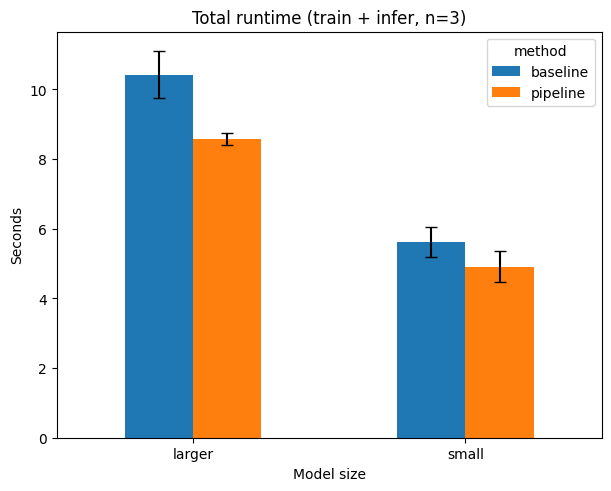

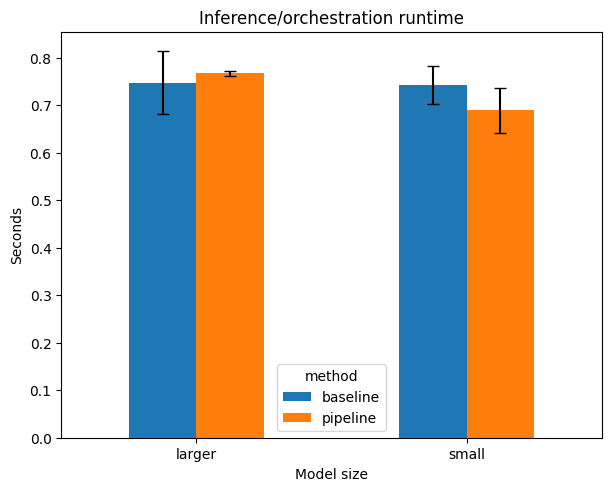

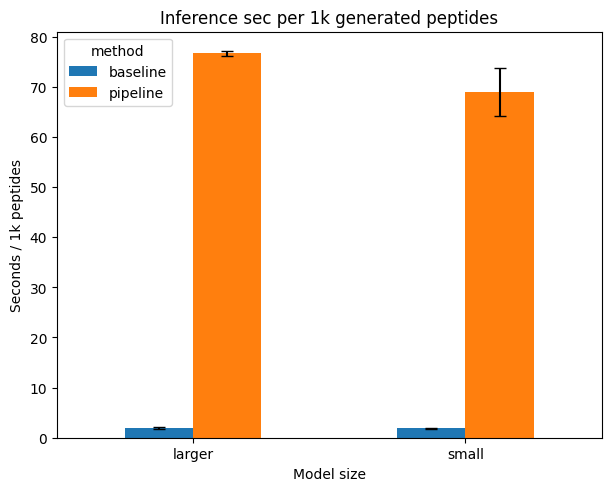

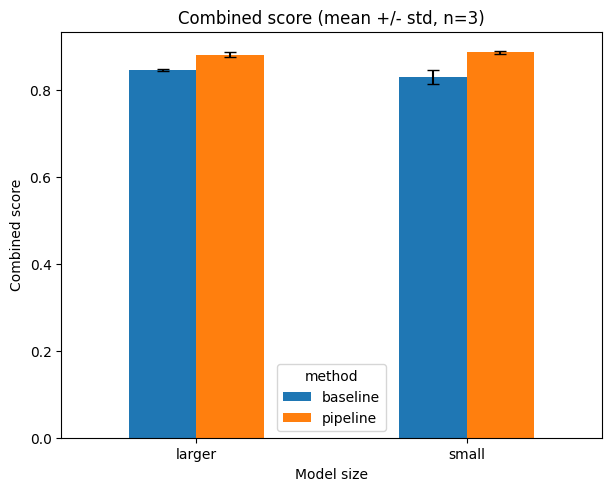

,method,setting,repeat,requested_budget,generated_count,train_sec,infer_sec,runtime_sec,sec_per_1k_generated,infer_sec_per_1k_generated
0,baseline,larger,1,384,384,9.936579,0.699390,10.635969,27.697836,1.821327
1,baseline,larger,2,384,384,8.942918,0.720711,9.663629,25.165700,1.876851
2,baseline,larger,3,384,384,10.148679,0.823492,10.972171,28.573362,2.144511
3,pipeline,larger,1,384,10,7.890098,0.761836,8.651935,865.193463,76.183615
4,pipeline,larger,2,384,10,7.903654,0.770283,8.673936,867.393647,77.028285
5,pipeline,larger,3,384,10,7.595958,0.768862,8.364820,836.481988,76.886192
6,baseline,small,1,384,384,4.499582,0.711763,5.211346,13.571212,1.853550
7,baseline,small,2,384,384,4.772431,0.787494,5.559925,14.478971,2.050766
8,baseline,small,3,384,384,5.345068,0.728881,6.073949,15.817575,1.898127
9,pipeline,small,1,384,10,3.841209,0.743631,4.584839,458.483935,74.363061


In [74]:
import time
import pickle

import matplotlib.pyplot as plt

from baseline.training import train_model
from baseline.inference import generate_peptides

from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from peptide_pipeline.biologist.base import BaseBiologist


def sequence_identity(seq, ref):
    if not seq or not ref:
        return 0.0
    n = min(len(seq), len(ref))
    matches = sum(1 for a, b in zip(seq[:n], ref[:n]) if a == b)
    return matches / max(len(ref), 1)


def summarize_identity(sequences, ref):
    clean = [s for s in sequences if isinstance(s, str) and s]
    if not clean:
        return {"best_identity": 0.0, "mean_identity": 0.0, "count": 0}
    ids = [sequence_identity(s, ref) for s in clean]
    return {
        "best_identity": float(max(ids)),
        "mean_identity": float(sum(ids) / len(ids)),
        "count": len(clean),
    }


def summarize_agent_scores(scored_rows):
    if not scored_rows:
        return {
            "chemist_mean": 0.0,
            "biologist_mean": 0.0,
            "combined_mean": 0.0,
            "combined_best": 0.0,
            "in_limits_rate": 0.0,
            "scored_count": 0,
        }

    chem = [float(r.get("chemist_score", 0.0)) for r in scored_rows]
    bio = [float(r.get("biologist_score", 0.0)) for r in scored_rows]
    comb = [float(r.get("combined_score", 0.0)) for r in scored_rows]
    in_limits = [1.0 if bool(r.get("in_limits", False)) else 0.0 for r in scored_rows]

    return {
        "chemist_mean": float(np.mean(chem)),
        "biologist_mean": float(np.mean(bio)),
        "combined_mean": float(np.mean(comb)),
        "combined_best": float(np.max(comb)),
        "in_limits_rate": float(np.mean(in_limits)),
        "scored_count": int(len(scored_rows)),
    }


def score_sequences_with_agents(sequences, chemist, biologist):
    clean = [s for s in sequences if isinstance(s, str) and s]
    if not clean:
        return []

    chem_rows = chemist.evaluate_peptides(clean)
    valid_rows = [r for r in chem_rows if isinstance(r, dict) and r.get("sequence")]
    peptides = [r["sequence"] for r in valid_rows]

    if not peptides:
        return []

    bio_scores = biologist.score_peptides(peptides)

    rows = []
    for c_row, b_score in zip(valid_rows, bio_scores):
        chem_score = float(c_row.get("score", 0.0))
        bio_score = float(b_score)
        combined = 0.5 * (chem_score + bio_score)
        rows.append(
            {
                "peptide": c_row["sequence"],
                "chemist_score": chem_score,
                "biologist_score": bio_score,
                "combined_score": combined,
                "in_limits": bool(c_row.get("in_limits", False)),
            }
        )
    return rows


class LocalFallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide):
        self.reference = reference_peptide

    def score_peptides(self, peptides):
        return [sequence_identity(p, self.reference) for p in peptides]


    def predict_activity(self, peptides, context=None):
        return self.score_peptides(peptides)


def get_biologist(reference_peptide):
    try:
        from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2

        return ESMBiologistGlobalL2(reference_peptide=reference_peptide, batch_size=16, score_temperature=50.0)
    except Exception as e:
        print(f"Using fallback biologist for benchmark: {e}")
        return LocalFallbackBiologist(reference_peptide=reference_peptide)


def build_chemist_from_target(target):
    return ChemistAgent(
        config=ChemistConfig(
            ph=7.0 if target["ph"] is None else float(target["ph"]),
            length=RangeTarget(min=8.0, max=14.0, target=float(target["length"]), weight=1.0),
            molecular_weight=RangeTarget(min=1200.0, max=2000.0, target=float(target["molecular_weight"]), weight=1.0),
            logp=RangeTarget(min=-3.0, max=3.0, target=float(target["logp"]), weight=1.0),
            net_charge=RangeTarget(min=2.0, max=8.0, target=float(target["net_charge"]), weight=1.0),
            isoelectric_point=RangeTarget(min=9.0, max=14.0, target=float(target["isoelectric_point"]), weight=1.0),
            hydrophobicity=RangeTarget(min=-2.0, max=3.0, target=float(target["hydrophobicity"]), weight=1.0),
        )
    )


def get_pipeline_training_tensors(max_len):
    if all(k in globals() for k in ["pipeline_df", "x", "conditions", "lengths"]):
        return pipeline_df.copy(), x, conditions, lengths

    aa = "ACDEFGHIKLMNPQRSTVWY"
    aa_to_idx = {a: i for i, a in enumerate(aa)}
    pad_idx = 20
    vocab_size = 21

    def encode_one_hot_with_pad_local(sequences, max_len_local):
        out = torch.zeros(len(sequences), max_len_local * vocab_size, dtype=torch.float32)
        for i, seq in enumerate(sequences):
            for pos in range(max_len_local):
                out[i, pos * vocab_size + pad_idx] = 1.0
            for pos, ch in enumerate(seq[:max_len_local]):
                if ch in aa_to_idx:
                    out[i, pos * vocab_size + pad_idx] = 0.0
                    out[i, pos * vocab_size + aa_to_idx[ch]] = 1.0
        return out

    def build_condition_tensor_local(dataframe, model):
        cond_local = torch.zeros(len(dataframe), model.condition_dim, dtype=torch.float32)
        cond_local[:, 0] = torch.tensor(dataframe["length"].values, dtype=torch.float32)
        cond_local[:, 1] = torch.tensor(dataframe["molecular_weight"].values, dtype=torch.float32)
        cond_local[:, 2] = torch.tensor(dataframe["net_charge"].values, dtype=torch.float32)
        cond_local[:, 3] = torch.tensor(dataframe["isoelectric_point"].values, dtype=torch.float32)
        cond_local[:, 4] = torch.tensor(dataframe["hydrophobicity"].values, dtype=torch.float32)
        cond_local[:, 5] = torch.tensor(dataframe["cathionicity"].values, dtype=torch.float32)
        cond_local[:, 6] = 0.5
        cond_local[:, 7] = torch.tensor(dataframe["logp"].values, dtype=torch.float32)
        cond_local[:, 8] = 0.0
        cond_local[:, 9] = 5.0
        cond_local[:, 10] = 5.0
        cond_local[:, 11] = 100.0
        return cond_local

    local_loader = JSONDataLoader()
    local_loader.load_data(
        source=str(DATA_PATH),
        columns=[
            "sequence",
            "length",
            "ph",
            "molecular_weight",
            "logp",
            "net_charge",
            "isoelectric_point",
            "hydrophobicity",
            "cathionicity",
        ],
        fillna_defaults={
            "length": 10,
            "ph": 7.0,
            "molecular_weight": 1500.0,
            "logp": 0.0,
            "net_charge": 0.0,
            "isoelectric_point": 7.0,
            "hydrophobicity": 0.0,
            "cathionicity": 0.0,
        },
        normalize_sequence=True,
        sequence_column="sequence",
        keep_standard_amino_acids_only=True,
    )
    df_local = local_loader.get_data().copy()

    cvae_tmp = CVAEGenerator(max_len=max_len, latent_dim=16, hidden_dim=128, condition_dim=32)
    x_local = encode_one_hot_with_pad_local(df_local["sequence"].tolist(), max_len_local=max_len)
    cond_local = build_condition_tensor_local(df_local, cvae_tmp)
    lengths_local = torch.tensor(df_local["length"].astype(int).values, dtype=torch.long)

    return df_local, x_local, cond_local, lengths_local


benchmark_settings = [
    {"label": "small", "epochs": 10, "latent_dim": 16, "hidden_dim": 128},
    {"label": "larger", "epochs": 20, "latent_dim": 32, "hidden_dim": 256},
]

bench_iterations = 8
bench_peptides = 48
bench_top_k = 10
benchmark_repeats = 3

# Fair generation budget: both methods are timed on the same number of requested candidates.
bench_total_budget = int(bench_iterations * bench_peptides)
bench_baseline_samples = bench_total_budget

benchmark_rows = []
ref_sequence = TARGET["sequence"]

pipe_df_local, x_local, cond_local, lengths_local = get_pipeline_training_tensors(SHARED_MAX_LEN)
x_local = x_local.to(torch.float32)
cond_local = cond_local.to(torch.float32)
lengths_local = lengths_local.to(torch.long)

benchmark_biologist = get_biologist(ref_sequence)

for cfg in benchmark_settings:
    label = cfg["label"]
    epochs = int(cfg["epochs"])
    latent_dim = int(cfg["latent_dim"])
    hidden_dim = int(cfg["hidden_dim"])

    for rep in range(1, benchmark_repeats + 1):
        seed_val = SEED + 50_000 + (1000 * (1 if label == "small" else 2)) + rep
        random.seed(seed_val)
        np.random.seed(seed_val)
        torch.manual_seed(seed_val)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed_val)

        chemist_cfg_agent = build_chemist_from_target(TARGET)

        baseline_model_path_cfg = EXPERIMENT_DIR / f"baseline_scale_{label}_rep{rep}_lat{latent_dim}_ep{epochs}.pth"
        baseline_scaler_path_cfg = EXPERIMENT_DIR / f"baseline_scale_{label}_rep{rep}_lat{latent_dim}_ep{epochs}_scaler.pkl"

        # Baseline training time (model fit + scaler loading)
        t0_train = time.perf_counter()
        baseline_model_cfg, _ = train_model(
            dataset_file=str(DATA_PATH),
            scaler_path=str(baseline_scaler_path_cfg),
            batch_size=SHARED_BATCH_SIZE,
            max_len=SHARED_MAX_LEN,
            epochs=epochs,
            latent_dim=latent_dim,
            model_path=str(baseline_model_path_cfg),
        )

        with open(baseline_scaler_path_cfg, "rb") as f:
            baseline_scaler_cfg = pickle.load(f)
        baseline_train_time = float(time.perf_counter() - t0_train)

        baseline_target_cfg = [
            TARGET["length"],
            7.0 if TARGET["ph"] is None else float(TARGET["ph"]),
            TARGET["molecular_weight"],
            TARGET["logp"],
            TARGET["net_charge"],
            TARGET["isoelectric_point"],
            TARGET["hydrophobicity"],
            TARGET["cathionicity"],
        ]

        # Baseline generation/evaluation time only
        t0_infer = time.perf_counter()
        baseline_sequences_cfg = generate_peptides(
            model=baseline_model_cfg,
            scaler=baseline_scaler_cfg,
            num_samples=bench_baseline_samples,
            properties=baseline_target_cfg,
            temperature=0.9,
            top_k=5,
        )
        baseline_scored_rows = score_sequences_with_agents(baseline_sequences_cfg, chemist_cfg_agent, benchmark_biologist)
        baseline_infer_time = float(time.perf_counter() - t0_infer)

        baseline_clean = [s for s in baseline_sequences_cfg if isinstance(s, str) and s]
        baseline_generated = int(len(baseline_clean))
        baseline_total_time = baseline_train_time + baseline_infer_time

        baseline_identity = summarize_identity(baseline_sequences_cfg, ref_sequence)
        baseline_agent_metrics = summarize_agent_scores(baseline_scored_rows)

        benchmark_rows.append(
            {
                "method": "baseline",
                "setting": label,
                "repeat": rep,
                "epochs": epochs,
                "latent_dim": latent_dim,
                "hidden_dim": None,
                "requested_budget": bench_baseline_samples,
                "generated_count": baseline_generated,
                "train_sec": baseline_train_time,
                "infer_sec": baseline_infer_time,
                "runtime_sec": baseline_total_time,
                "sec_per_1k_generated": 1000.0 * baseline_total_time / max(baseline_generated, 1),
                "infer_sec_per_1k_generated": 1000.0 * baseline_infer_time / max(baseline_generated, 1),
                **baseline_identity,
                **baseline_agent_metrics,
            }
        )

        pipeline_model_path_cfg = EXPERIMENT_DIR / f"pipeline_scale_{label}_rep{rep}_lat{latent_dim}_hid{hidden_dim}_ep{epochs}.pth"

        # Pipeline training time
        t1_train = time.perf_counter()
        pipeline_cvae_cfg = CVAEGenerator(
            max_len=SHARED_MAX_LEN,
            latent_dim=latent_dim,
            hidden_dim=hidden_dim,
            condition_dim=32,
        )

        pipeline_cvae_cfg.train_model(
            data=x_local.to(pipeline_cvae_cfg.device),
            conditions=cond_local.to(pipeline_cvae_cfg.device),
            lengths=lengths_local.to(pipeline_cvae_cfg.device),
            epochs=epochs,
            batch_size=SHARED_BATCH_SIZE,
            lr=1e-3,
            kl_anneal_epochs=max(1, epochs // 2),
        )
        pipeline_cvae_cfg.save_model(str(pipeline_model_path_cfg))
        pipeline_train_time = float(time.perf_counter() - t1_train)

        orchestrator_cfg = Orchestrator(
            generator=pipeline_cvae_cfg,
            chemist=chemist_cfg_agent,
            biologist=benchmark_biologist,
        )

        # Pipeline generation/evaluation loop time only
        t1_infer = time.perf_counter()
        pipe_rows_cfg = orchestrator_cfg.run(
            nb_iterations=bench_iterations,
            nb_peptides=bench_peptides,
            top_k=bench_top_k,
            exploration_rate=0.15,
            initial_peptide=ref_sequence,
            final_target={
                "length": TARGET["length"],
                "molecular_weight": TARGET["molecular_weight"],
                "logp": TARGET["logp"],
                "net_charge": TARGET["net_charge"],
                "isoelectric_point": TARGET["isoelectric_point"],
                "hydrophobicity": TARGET["hydrophobicity"],
                "cathionicity": TARGET["cathionicity"],
            },
        )
        pipeline_infer_time = float(time.perf_counter() - t1_infer)

        pipe_sequences_cfg = [r.get("peptide", "") for r in pipe_rows_cfg if isinstance(r, dict)]
        pipeline_generated = int(len([s for s in pipe_sequences_cfg if isinstance(s, str) and s]))
        pipeline_total_time = pipeline_train_time + pipeline_infer_time

        pipeline_identity = summarize_identity(pipe_sequences_cfg, ref_sequence)
        pipeline_scored_rows = [
            {
                "peptide": r.get("peptide", ""),
                "chemist_score": float(r.get("chemist_score", 0.0)),
                "biologist_score": float(r.get("biologist_score", 0.0)),
                "combined_score": float(r.get("combined_score", r.get("score", 0.0))),
                "in_limits": bool(r.get("in_limits", False)),
            }
            for r in pipe_rows_cfg
            if isinstance(r, dict)
        ]
        pipeline_agent_metrics = summarize_agent_scores(pipeline_scored_rows)

        benchmark_rows.append(
            {
                "method": "pipeline",
                "setting": label,
                "repeat": rep,
                "epochs": epochs,
                "latent_dim": latent_dim,
                "hidden_dim": hidden_dim,
                "requested_budget": bench_total_budget,
                "generated_count": pipeline_generated,
                "train_sec": pipeline_train_time,
                "infer_sec": pipeline_infer_time,
                "runtime_sec": pipeline_total_time,
                "sec_per_1k_generated": 1000.0 * pipeline_total_time / max(pipeline_generated, 1),
                "infer_sec_per_1k_generated": 1000.0 * pipeline_infer_time / max(pipeline_generated, 1),
                **pipeline_identity,
                **pipeline_agent_metrics,
            }
        )

benchmark_raw_df = pd.DataFrame(benchmark_rows)
benchmark_summary_df = pd.DataFrame()

if not benchmark_raw_df.empty:
    fixed_df = benchmark_raw_df.copy()
    fixed_df["hidden_dim_group"] = fixed_df["hidden_dim"].fillna(-1).astype(int)

    benchmark_summary_df = fixed_df.groupby(
        ["setting", "method", "epochs", "latent_dim", "hidden_dim_group"],
        as_index=False,
    ).agg(
        requested_budget_mean=("requested_budget", "mean"),
        generated_count_mean=("generated_count", "mean"),
        train_sec_mean=("train_sec", "mean"),
        train_sec_std=("train_sec", "std"),
        infer_sec_mean=("infer_sec", "mean"),
        infer_sec_std=("infer_sec", "std"),
        runtime_sec_mean=("runtime_sec", "mean"),
        runtime_sec_std=("runtime_sec", "std"),
        sec_per_1k_generated_mean=("sec_per_1k_generated", "mean"),
        sec_per_1k_generated_std=("sec_per_1k_generated", "std"),
        infer_sec_per_1k_generated_mean=("infer_sec_per_1k_generated", "mean"),
        infer_sec_per_1k_generated_std=("infer_sec_per_1k_generated", "std"),
        chemist_mean_mean=("chemist_mean", "mean"),
        chemist_mean_std=("chemist_mean", "std"),
        biologist_mean_mean=("biologist_mean", "mean"),
        biologist_mean_std=("biologist_mean", "std"),
        combined_mean_mean=("combined_mean", "mean"),
        combined_mean_std=("combined_mean", "std"),
        combined_best_mean=("combined_best", "mean"),
        combined_best_std=("combined_best", "std"),
        in_limits_rate_mean=("in_limits_rate", "mean"),
        in_limits_rate_std=("in_limits_rate", "std"),
        best_identity_mean=("best_identity", "mean"),
        best_identity_std=("best_identity", "std"),
        mean_identity_mean=("mean_identity", "mean"),
        mean_identity_std=("mean_identity", "std"),
        scored_count_mean=("scored_count", "mean"),
    )

    benchmark_summary_df["hidden_dim"] = benchmark_summary_df["hidden_dim_group"].replace({-1: np.nan})
    benchmark_summary_df = benchmark_summary_df.drop(columns=["hidden_dim_group"])
    benchmark_summary_df = benchmark_summary_df.sort_values(["setting", "method"]).reset_index(drop=True)

display(benchmark_summary_df)
display(benchmark_raw_df.head(8))

if not benchmark_summary_df.empty:
    total_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="runtime_sec_mean")
    total_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="runtime_sec_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    total_pivot.plot(kind="bar", yerr=total_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Total runtime (train + infer, n={benchmark_repeats})")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Seconds")
    plt.show()

    infer_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_mean")
    infer_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    infer_pivot.plot(kind="bar", yerr=infer_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Inference/orchestration runtime")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Seconds")
    plt.show()

    norm_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_per_1k_generated_mean")
    norm_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="infer_sec_per_1k_generated_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    norm_pivot.plot(kind="bar", yerr=norm_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Inference sec per 1k generated peptides")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Seconds / 1k peptides")
    plt.show()

    quality_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="combined_mean_mean")
    quality_err_pivot = benchmark_summary_df.pivot(index="setting", columns="method", values="combined_mean_std").fillna(0.0)
    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
    quality_pivot.plot(kind="bar", yerr=quality_err_pivot, capsize=4, ax=ax, rot=0)
    ax.set_title(f"Combined score (mean +/- std, n={benchmark_repeats})")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Combined score")
    plt.show()

runtime_check_df = pd.DataFrame()
if not benchmark_raw_df.empty:
    runtime_check_df = benchmark_raw_df[
        [
            "method",
            "setting",
            "repeat",
            "requested_budget",
            "generated_count",
            "train_sec",
            "infer_sec",
            "runtime_sec",
            "sec_per_1k_generated",
            "infer_sec_per_1k_generated",
        ]
    ].sort_values(["setting", "method", "repeat"]).reset_index(drop=True)
    display(runtime_check_df)


## Harder Target-Length Experiment (Length 12 vs Length 5)

This experiment now compares four agents on two target lengths:
- Baseline
- Pipeline very-low-iteration (1 iteration)
- Pipeline low-iteration (3 iterations)
- Pipeline high-iteration (10 iterations)

Target lengths:
- Length 12 (easier/standard regime)
- Length 5 (harder regime)

Protocol:
- Same generator models as previously loaded in this notebook
- Repeated runs with different seeds
- Combined score = 0.5 * (chemist score + biologist score)
- We report average combined score for all four agents at length 12 and length 5

In [83]:
# This cell is intentionally robust if run independently after the core setup cells.
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator
from baseline.model import PeptideCVAE
from baseline.data_handler import VOCAB
from contextlib import contextmanager
from pathlib import Path
import pickle


@contextmanager
def _force_cpu_cuda_flag():
    original_cuda_available = torch.cuda.is_available
    torch.cuda.is_available = lambda: False
    try:
        yield
    finally:
        torch.cuda.is_available = original_cuda_available


def _sequence_identity(seq, ref):
    if not seq or not ref:
        return 0.0
    n = min(len(seq), len(ref))
    matches = sum(1 for a, b in zip(seq[:n], ref[:n]) if a == b)
    return matches / max(len(ref), 1)


class _FallbackBiologistForLengthTest:
    def __init__(self, reference_peptide):
        self.reference = reference_peptide

    def score_peptides(self, peptides):
        return [_sequence_identity(p, self.reference) for p in peptides]


def _get_biologist_for_length_test(reference_peptide):
    if "get_biologist" in globals():
        try:
            return get_biologist(reference_peptide)
        except Exception as e:
            print(f"Using local fallback biologist (get_biologist failed): {e}")
    return _FallbackBiologistForLengthTest(reference_peptide)


def _score_sequences_with_agents_local(sequences, chemist, biologist):
    clean = [s for s in sequences if isinstance(s, str) and s]
    if not clean:
        return []

    chem_rows = chemist.evaluate_peptides(clean)
    valid_rows = [r for r in chem_rows if isinstance(r, dict) and r.get("sequence")]
    peptides = [r["sequence"] for r in valid_rows]
    if not peptides:
        return []

    bio_scores = biologist.score_peptides(peptides)
    rows = []
    for c_row, b_score in zip(valid_rows, bio_scores):
        chem_score = float(c_row.get("score", 0.0))
        bio_score = float(b_score)
        rows.append(
            {
                "peptide": c_row["sequence"],
                "combined_score": 0.5 * (chem_score + bio_score),
            }
        )
    return rows


def _summarize_combined_mean(scored_rows):
    if not scored_rows:
        return 0.0
    vals = [float(r.get("combined_score", 0.0)) for r in scored_rows]
    return float(np.mean(vals))


def _ensure_pipeline_df_loaded():
    if "pipeline_df" in globals() and pipeline_df is not None and not pipeline_df.empty:
        return

    local_loader = JSONDataLoader()
    local_loader.load_data(
        source=str(DATA_PATH),
        columns=[
            "sequence",
            "length",
            "ph",
            "molecular_weight",
            "logp",
            "net_charge",
            "isoelectric_point",
            "hydrophobicity",
            "cathionicity",
        ],
        fillna_defaults={
            "length": 10,
            "ph": 7.0,
            "molecular_weight": 1500.0,
            "logp": 0.0,
            "net_charge": 0.0,
            "isoelectric_point": 7.0,
            "hydrophobicity": 0.0,
            "cathionicity": 0.0,
        },
        normalize_sequence=True,
        sequence_column="sequence",
        keep_standard_amino_acids_only=True,
    )
    globals()["pipeline_df"] = local_loader.get_data().copy()


def _ensure_pipeline_generator_loaded():
    model_path = EXPERIMENT_DIR / (
        f"pipeline_cvae_model_lat{PIPELINE_LATENT_DIM}_hid{PIPELINE_HIDDEN_DIM}_ep{PIPELINE_EPOCHS}_bs{PIPELINE_BATCH_SIZE}.pth"
    )
    if not model_path.exists():
        raise RuntimeError(
            f"Pipeline model not found at {model_path}. Run the pipeline training/loading cell first."
        )

    with _force_cpu_cuda_flag():
        cvae = CVAEGenerator(
            max_len=SHARED_MAX_LEN,
            latent_dim=PIPELINE_LATENT_DIM,
            hidden_dim=PIPELINE_HIDDEN_DIM,
            condition_dim=32,
        )
    cvae.load_model(str(model_path))
    cvae.to(torch.device("cpu"))
    cvae.device = torch.device("cpu")
    globals()["pipeline_cvae"] = cvae


def _ensure_baseline_loaded_cpu():
    model_path = globals().get("baseline_model_path", EXPERIMENT_DIR / "baseline_cvae_model.pth")
    scaler_path = globals().get("baseline_scaler_path", EXPERIMENT_DIR / "baseline_scaler.pkl")

    model_path = Path(model_path)
    scaler_path = Path(scaler_path)

    if not model_path.exists():
        raise RuntimeError(f"Baseline model not found at {model_path}. Run baseline training cell first.")
    if not scaler_path.exists():
        raise RuntimeError(f"Baseline scaler not found at {scaler_path}. Run baseline training cell first.")

    baseline_cpu = PeptideCVAE(
        vocab_size=len(VOCAB),
        condition_dim=8,
        max_seq_len=SHARED_MAX_LEN + 2,
        latent_dim=SHARED_LATENT_DIM,
    )
    state = torch.load(model_path, map_location=torch.device("cpu"))
    baseline_cpu.load_state_dict(state)
    baseline_cpu = baseline_cpu.to(torch.device("cpu"))

    with open(scaler_path, "rb") as f:
        scaler_obj = pickle.load(f)

    globals()["baseline_model"] = baseline_cpu
    globals()["baseline_scaler"] = scaler_obj


def _select_target_by_length(target_length):
    fixed_target = dict(TARGET)
    fixed_target["length"] = int(target_length)

    ph_raw = fixed_target.get("ph", None)
    ph_val = 7.0 if pd.isna(ph_raw) else float(ph_raw)

    return {
        "sequence": str(fixed_target["sequence"]),
        "length": int(fixed_target["length"]),
        "ph": ph_val,
        "molecular_weight": float(fixed_target["molecular_weight"]),
        "logp": float(fixed_target["logp"]),
        "net_charge": float(fixed_target["net_charge"]),
        "isoelectric_point": float(fixed_target["isoelectric_point"]),
        "hydrophobicity": float(fixed_target["hydrophobicity"]),
        "cathionicity": float(fixed_target["cathionicity"]),
    }


def _build_chemist_for_target(target):
    tlen = int(target["length"])

    def _range_around(value, margin, lower=None, upper=None):
        v = float(value)
        lo = v - float(margin)
        hi = v + float(margin)

        if lower is not None:
            lo = max(lo, float(lower))
        if upper is not None:
            hi = min(hi, float(upper))

        lo = min(lo, v)
        hi = max(hi, v)
        return float(lo), float(hi)

    len_min, len_max = _range_around(tlen, margin=2.0, lower=2.0, upper=14.0)
    mw_min, mw_max = _range_around(target["molecular_weight"], margin=500.0, lower=100.0, upper=3000.0)
    logp_min, logp_max = _range_around(target["logp"], margin=2.5, lower=-8.0, upper=8.0)
    charge_min, charge_max = _range_around(target["net_charge"], margin=4.0, lower=-8.0, upper=12.0)
    pI_min, pI_max = _range_around(target["isoelectric_point"], margin=3.0, lower=2.0, upper=14.0)
    hydro_min, hydro_max = _range_around(target["hydrophobicity"], margin=2.5, lower=-8.0, upper=8.0)

    cfg = ChemistConfig(
        ph=7.0 if target["ph"] is None else float(target["ph"]),
        length=RangeTarget(min=len_min, max=len_max, target=float(target["length"]), weight=1.0),
        molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=float(target["molecular_weight"]), weight=1.0),
        logp=RangeTarget(min=logp_min, max=logp_max, target=float(target["logp"]), weight=1.0),
        net_charge=RangeTarget(min=charge_min, max=charge_max, target=float(target["net_charge"]), weight=1.0),
        isoelectric_point=RangeTarget(min=pI_min, max=pI_max, target=float(target["isoelectric_point"]), weight=1.0),
        hydrophobicity=RangeTarget(min=hydro_min, max=hydro_max, target=float(target["hydrophobicity"]), weight=1.0),
    )
    return ChemistAgent(config=cfg)


def _run_target_length_comparison(target_length, n_runs=5):
    target_local = _select_target_by_length(target_length)
    biologist_local = _get_biologist_for_length_test(target_local["sequence"])
    records = []

    local_peptides = int(globals().get("bench_peptides", 48))
    local_top_k = int(globals().get("bench_top_k", 10))

    pipeline_iteration_configs = [
        ("pipeline_1_iter", 1),
        ("pipeline_3_iter", 3),
        ("pipeline_10_iter", 10),
    ]

    # Baseline is sampled once with the high-iteration budget for a stable reference.
    baseline_budget = int(max(it for _, it in pipeline_iteration_configs) * local_peptides)

    baseline_properties = [
        target_local["length"],
        7.0 if target_local["ph"] is None else float(target_local["ph"]),
        target_local["molecular_weight"],
        target_local["logp"],
        target_local["net_charge"],
        target_local["isoelectric_point"],
        target_local["hydrophobicity"],
        target_local["cathionicity"],
    ]

    for run_idx in range(1, n_runs + 1):
        run_seed = SEED + 70000 + (100 * int(target_length)) + run_idx
        random.seed(run_seed)
        np.random.seed(run_seed)
        try:
            torch.random.default_generator.manual_seed(run_seed)
        except Exception as e:
            print(f"Warning: torch seed not set for this run ({e})")

        chemist_local = _build_chemist_for_target(target_local)

        with _force_cpu_cuda_flag():
            baseline_sequences_local = generate_peptides(
                model=baseline_model,
                scaler=baseline_scaler,
                num_samples=baseline_budget,
                properties=baseline_properties,
                temperature=0.9,
                top_k=5,
            )

        baseline_rows = _score_sequences_with_agents_local(
            baseline_sequences_local,
            chemist_local,
            biologist_local,
        )
        baseline_combined_mean = _summarize_combined_mean(baseline_rows)
        baseline_clean_sequences = [s for s in baseline_sequences_local if isinstance(s, str) and s]
        baseline_generated_count = int(len(baseline_clean_sequences))
        baseline_unique_count = int(len(set(baseline_clean_sequences)))
        baseline_duplicate_count = int(max(0, baseline_generated_count - baseline_unique_count))
        baseline_duplicate_rate = float(baseline_duplicate_count / max(baseline_generated_count, 1))

        records.append(
            {
                "target_length": int(target_length),
                "run": run_idx,
                "method": "baseline",
                "iterations": None,
                "requested_budget": baseline_budget,
                "avg_combined": float(baseline_combined_mean),
                "generated_count": baseline_generated_count,
                "unique_count": baseline_unique_count,
                "duplicate_count": baseline_duplicate_count,
                "duplicate_rate": baseline_duplicate_rate,
                "topk_generated_count": baseline_generated_count,
                "topk_unique_count": baseline_unique_count,
                "topk_duplicate_count": baseline_duplicate_count,
                "topk_duplicate_rate": baseline_duplicate_rate,
                "target_sequence": target_local["sequence"],
            }
        )

        for method_name, iter_count in pipeline_iteration_configs:
            orchestrator_local = Orchestrator(
                generator=pipeline_cvae,
                chemist=chemist_local,
                biologist=biologist_local,
            )
            pipeline_constraints = {
                "size": float(target_local["length"]),
                "molecular_weight": float(target_local["molecular_weight"]),
                "net_charge_pH5_5": float(target_local["net_charge"]),
                "isoelectric_point": float(target_local["isoelectric_point"]),
                "hydrophobicity": float(target_local["hydrophobicity"]),
                "cathionicity": float(target_local["cathionicity"]),
                "logp": float(target_local["logp"]),
            }

            requested_budget = int(iter_count * local_peptides)
            pipeline_sequences_local = []
            try:
                pipeline_rows_local = orchestrator_local.run(
                    nb_iterations=iter_count,
                    nb_peptides=local_peptides,
                    top_k=local_top_k,
                    exploration_rate=0.15,
                    initial_peptide=target_local["sequence"],
                    final_target={
                        "length": target_local["length"],
                        "molecular_weight": target_local["molecular_weight"],
                        "logp": target_local["logp"],
                        "net_charge": target_local["net_charge"],
                        "isoelectric_point": target_local["isoelectric_point"],
                        "hydrophobicity": target_local["hydrophobicity"],
                        "cathionicity": target_local["cathionicity"],
                    },
                )

                pipeline_scored = [
                    float(r.get("combined_score", r.get("score", 0.0)))
                    for r in pipeline_rows_local
                    if isinstance(r, dict)
                ]
                pipeline_combined_mean = float(np.mean(pipeline_scored)) if pipeline_scored else 0.0
                pipeline_sequences_local = [
                    str(r.get("peptide", ""))
                    for r in pipeline_rows_local
                    if isinstance(r, dict) and isinstance(r.get("peptide", ""), str) and r.get("peptide", "")
                ]
            except Exception as e:
                print(f"Pipeline orchestrator fallback for length {target_length}, run {run_idx}, {method_name}: {e}")
                try:
                    pipeline_peptides = pipeline_cvae.generate_peptides(
                        count=requested_budget,
                        constraints=pipeline_constraints,
                    )
                    pipeline_rows_fallback = _score_sequences_with_agents_local(
                        pipeline_peptides,
                        chemist_local,
                        biologist_local,
                    )
                    pipeline_combined_mean = _summarize_combined_mean(pipeline_rows_fallback)
                    pipeline_sequences_local = [s for s in pipeline_peptides if isinstance(s, str) and s]
                except Exception as e2:
                    print(f"Pipeline direct-generation fallback also failed ({method_name}): {e2}")
                    try:
                        pipeline_peptides = pipeline_cvae.generate_peptides(
                            count=requested_budget,
                            constraints=None,
                        )
                        pipeline_rows_fallback = _score_sequences_with_agents_local(
                            pipeline_peptides,
                            chemist_local,
                            biologist_local,
                        )
                        pipeline_combined_mean = _summarize_combined_mean(pipeline_rows_fallback)
                        pipeline_sequences_local = [s for s in pipeline_peptides if isinstance(s, str) and s]
                    except Exception as e3:
                        print(f"Pipeline length-only fallback also failed ({method_name}): {e3}")
                        pipeline_combined_mean = 0.0
                        pipeline_sequences_local = []

            pipeline_topk_generated_count = int(len(pipeline_sequences_local))
            pipeline_topk_unique_count = int(len(set(pipeline_sequences_local)))
            pipeline_topk_duplicate_count = int(max(0, pipeline_topk_generated_count - pipeline_topk_unique_count))
            pipeline_topk_duplicate_rate = float(pipeline_topk_duplicate_count / max(pipeline_topk_generated_count, 1))

            try:
                pipeline_budget_peptides = pipeline_cvae.generate_peptides(
                    count=requested_budget,
                    constraints=pipeline_constraints,
                )
            except Exception as e:
                print(f"Pipeline budget diversity generation failed ({method_name}): {e}")
                try:
                    pipeline_budget_peptides = pipeline_cvae.generate_peptides(
                        count=requested_budget,
                        constraints=None,
                    )
                except Exception as e2:
                    print(f"Pipeline unconstrained diversity fallback failed ({method_name}): {e2}")
                    pipeline_budget_peptides = []

            pipeline_budget_sequences = [s for s in pipeline_budget_peptides if isinstance(s, str) and s]
            pipeline_generated_count = int(len(pipeline_budget_sequences))
            pipeline_unique_count = int(len(set(pipeline_budget_sequences)))
            pipeline_duplicate_count = int(max(0, pipeline_generated_count - pipeline_unique_count))
            pipeline_duplicate_rate = float(pipeline_duplicate_count / max(pipeline_generated_count, 1))

            records.append(
                {
                    "target_length": int(target_length),
                    "run": run_idx,
                    "method": method_name,
                    "iterations": iter_count,
                    "requested_budget": requested_budget,
                    "avg_combined": float(pipeline_combined_mean),
                    "generated_count": pipeline_generated_count,
                    "unique_count": pipeline_unique_count,
                    "duplicate_count": pipeline_duplicate_count,
                    "duplicate_rate": pipeline_duplicate_rate,
                    "topk_generated_count": pipeline_topk_generated_count,
                    "topk_unique_count": pipeline_topk_unique_count,
                    "topk_duplicate_count": pipeline_topk_duplicate_count,
                    "topk_duplicate_rate": pipeline_topk_duplicate_rate,
                    "target_sequence": target_local["sequence"],
                }
            )

    return pd.DataFrame(records)


_ensure_baseline_loaded_cpu()

_ensure_pipeline_df_loaded()
_ensure_pipeline_generator_loaded()

lengths_to_compare = [n for n in range(4,12)]
repeat_runs = 5

hardness_rows = []
for length_value in lengths_to_compare:
    df_len = _run_target_length_comparison(target_length=length_value, n_runs=repeat_runs)
    hardness_rows.append(df_len)

hardness_raw_df = pd.concat(hardness_rows, ignore_index=True) if hardness_rows else pd.DataFrame()

if hardness_raw_df.empty:
    print("No results produced for the hard target-length experiment.")
else:
    display(hardness_raw_df)

    hardness_summary_df = (
        hardness_raw_df.groupby(["target_length", "method"], as_index=False)
        .agg(
            requested_budget_mean=("requested_budget", "mean"),
            avg_score=("avg_combined", "mean"),
            std_score=("avg_combined", "std"),
        )
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )

    hardness_variety_summary_df = (
        hardness_raw_df.groupby(["target_length", "method"], as_index=False)
        .agg(
            requested_budget_mean=("requested_budget", "mean"),
            generated_mean=("generated_count", "mean"),
            unique_mean=("unique_count", "mean"),
            duplicate_mean=("duplicate_count", "mean"),
            duplicate_rate_mean=("duplicate_rate", "mean"),
            duplicate_rate_std=("duplicate_rate", "std"),
            topk_generated_mean=("topk_generated_count", "mean"),
            topk_unique_mean=("topk_unique_count", "mean"),
            topk_duplicate_mean=("topk_duplicate_count", "mean"),
            topk_duplicate_rate_mean=("topk_duplicate_rate", "mean"),
            topk_duplicate_rate_std=("topk_duplicate_rate", "std"),
        )
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )

    display(hardness_summary_df)
    display(hardness_variety_summary_df)

    print("Average combined score by target length and method:")
    for target_len in sorted(hardness_summary_df["target_length"].unique(), reverse=True):
        part = hardness_summary_df[hardness_summary_df["target_length"] == target_len]
        print(f"Length {int(target_len):2d}:")
        for _, row in part.iterrows():
            print(f"  - {row['method']}: mean={float(row['avg_score']):.4f}, std={float(row['std_score']) if pd.notna(row['std_score']) else 0.0:.4f}")

    print("Average duplicate rate by target length and method:")
    for target_len in sorted(hardness_variety_summary_df["target_length"].unique(), reverse=True):
        part = hardness_variety_summary_df[hardness_variety_summary_df["target_length"] == target_len]
        print(f"Length {int(target_len):2d}:")
        for _, row in part.iterrows():
            print(
                f"  - {row['method']}: dup_rate={float(row['duplicate_rate_mean']):.3f}, "
                f"generated={float(row['generated_mean']):.1f}, unique={float(row['unique_mean']):.1f}"
            )

2026-03-24 11:28:04,221 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:28:04,241 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/config.json "HTTP/1.1 200 OK"
2026-03-24 11:28:04,363 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/facebook/esm2_t12_35M_UR50D/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 11:28:04,379 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/esm2_t12_35M_UR50D/6fbf070e65b0b7291e7bbcd451118c216cff79d8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-24 11:28:04,515 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/esm2_t12_35M_UR50D/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-24 11:2

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1058.01it/s, Materializing param=encoder.layer.11.output.dense.weight]                     
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu
Model loaded successfully.

Target Properties:
- Length: 4.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 480 novel peptide(s) ---
Sample 1: KKKRK
Sample 2: KKKKK
Sample 3: KKKRK
Sample 4: KKKRK
Sample 5: KKKRK
Sample 6: KKKRK
Sample 7: KKKR
Sample 8: KKKRK
Sample 9: KKKRK
Sample 10: KKRKR
Sample 11: KKKRK
Sample 12: KKKRR
Sample 13: KKKRK
Sample 14: KKKKK
Sample 15: KKKR
Sample 16: KKKRK
Sample 17: KKKKK
Sample 18: KKKKK
Sample 19: KKKR
Sample 20: KKKKK
Sample 21: KKKRK
Sample 22: KKKRK
Sample 23: KKKRR
Sample 24: KKKKK
Sample 25: KKKRK
Sample 26: KKKKK
Sample 27: KKKRK
Sample 28: KKKRK
Sample 29: KKKRK
Sample 30: KKKRK
Sample 31: KKKRK
Sample 32: KKKRK
Sample 33: KKKRK
Sample 34: KKKRK
Sample 35: KKKRK
Sample 36: KKKKK
Sample 37: KKKRK
Sample 38: KKRKR
Sample 39: KKKRK
Sample 40: KKKKR
Sample 41: KKKRK
Sample 42: KKKKK
Sample 43: KKK

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1282.73it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu
Model loaded successfully.

Target Properties:
- Length: 5.0
- pH: 7.0
- Molecular Weight: 1558.9480000000003
- LogP: -0.992100000000006
- Net Charge: 5.0
- Isoelectric Point: 12.18
- Hydrophobicity: 1.05
- Cathionicity: 6.0

--- Generating 480 novel peptide(s) ---
Sample 1: KKKKK
Sample 2: KKKRKR
Sample 3: KKKRK
Sample 4: KKKRK
Sample 5: KKKRKK
Sample 6: KRKKK
Sample 7: KKKRKR
Sample 8: KKKRRR
Sample 9: KKKKRK
Sample 10: KKKKKR
Sample 11: KKKRK
Sample 12: KKKRK
Sample 13: KKKRKR
Sample 14: KKKKK
Sample 15: KRKKR
Sample 16: KKKRK
Sample 17: KKKRKR
Sample 18: KKKKK
Sample 19: KKKRK
Sample 20: KKKRK
Sample 21: KKKKK
Sample 22: KKKKK
Sample 23: KRKKK
Sample 24: KKKKK
Sample 25: KKKKR
Sample 26: KKKKK
Sample 27: KKKRKR
Sample 28: KRKKR
Sample 29: KKKRKR
Sample 30: KKKKRK
Sample 31: KKKKKK
Sample 32: KKKRK
Sample 33: KKKKK
Sample 34: KKKKKK
Sample 35: KKKKRK
Sample 36: KKKKK
Sample 37: KKKKKK
Sample 38: KKKKKK
Sample 39: KKKKKR
Sample 40: KKKKK
Sample 41: KKKKKK
Sample 42:

...

2026-03-24 11:29:18,825 - peptide_pipeline.orchestrator - INFO - Iteration 1: mode=target_only, generated=48, in_limits=5, off_limits=43, best_combined=0.8048, global_unique=5
2026-03-24 11:29:18,949 - peptide_pipeline.orchestrator - INFO - Iteration 2: mode=exploitation_top, generated=48, in_limits=3, off_limits=45, best_combined=0.7662, global_unique=8
2026-03-24 11:29:19,047 - peptide_pipeline.orchestrator - INFO - Iteration 3: mode=exploitation_top, generated=48, in_limits=1, off_limits=47, best_combined=0.7362, global_unique=9
2026-03-24 11:29:19,139 - peptide_pipeline.orchestrator - INFO - Iteration 4: mode=exploitation_top, generated=48, in_limits=2, off_limits=46, best_combined=0.8211, global_unique=11
2026-03-24 11:29:19,216 - peptide_pipeline.orchestrator - INFO - Iteration 5: mode=exploitation_top, generated=48, in_limits=1, off_limits=47, best_combined=0.7595, global_unique=12
2026-03-24 11:29:19,294 - peptide_pipeline.orchestrator - INFO - Iteration 6: mode=exploration_ran

,target_length,run,method,iterations,requested_budget,avg_combined,generated_count,unique_count,duplicate_count,duplicate_rate,topk_generated_count,topk_unique_count,topk_duplicate_count,topk_duplicate_rate,target_sequence
0,4,1,baseline,NaN,480,0.609013,480,19,461,0.960417,480,19,461,0.960417,KLFKRWKHLFR
1,4,1,pipeline_1_iter,1.0,48,0.626377,48,48,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
2,4,1,pipeline_3_iter,3.0,144,0.652105,144,144,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
3,4,1,pipeline_10_iter,10.0,480,0.671360,480,480,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
4,4,2,baseline,NaN,480,0.611329,480,17,463,0.964583,480,17,463,0.964583,KLFKRWKHLFR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,11,4,pipeline_10_iter,10.0,480,0.775075,480,480,0,0.000000,10,10,0,0.000000,KLFKRWKHLFR
156,11,5,baseline,NaN,480,0.836440,480,351,129,0.268750,480,351,129,0.268750,KLFKRWKHLFR
157,11,5,pipeline_1_iter,1.0,48,0.779819,48,48,0,0.000000,3,3,0,0.000000,KLFKRWKHLFR
158,11,5,pipeline_3_iter,3.0,144,0.756172,144,144,0,0.000000,8,8,0,0.000000,KLFKRWKHLFR


,target_length,method,requested_budget_mean,avg_score,std_score
0,11,baseline,480.0,0.834997,0.001594
1,11,pipeline_10_iter,480.0,0.782683,0.012949
2,11,pipeline_1_iter,48.0,0.771319,0.022079
3,11,pipeline_3_iter,144.0,0.756908,0.008581
4,10,baseline,480.0,0.787747,0.000447
5,10,pipeline_10_iter,480.0,0.776700,0.012163
6,10,pipeline_1_iter,48.0,0.742744,0.023593
7,10,pipeline_3_iter,144.0,0.748446,0.014210
8,9,baseline,480.0,0.720091,0.002755
9,9,pipeline_10_iter,480.0,0.772468,0.004901


,target_length,method,requested_budget_mean,generated_mean,unique_mean,duplicate_mean,duplicate_rate_mean,duplicate_rate_std,topk_generated_mean,topk_unique_mean,topk_duplicate_mean,topk_duplicate_rate_mean,topk_duplicate_rate_std
0,11,baseline,480.0,480.0,353.2,126.8,0.264167,0.005187,480.0,353.2,126.8,0.264167,0.005187
1,11,pipeline_10_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
2,11,pipeline_1_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,4.0,4.0,0.0,0.000000,0.000000
3,11,pipeline_3_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,9.0,9.0,0.0,0.000000,0.000000
4,10,baseline,480.0,480.0,418.6,61.4,0.127917,0.013307,480.0,418.6,61.4,0.127917,0.013307
5,10,pipeline_10_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
6,10,pipeline_1_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.8,2.8,0.0,0.000000,0.000000
7,10,pipeline_3_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,8.6,8.6,0.0,0.000000,0.000000
8,9,baseline,480.0,480.0,359.0,121.0,0.252083,0.017180,480.0,359.0,121.0,0.252083,0.017180
9,9,pipeline_10_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000


Average combined score by target length and method:
Length 11:
  - baseline: mean=0.8350, std=0.0016
  - pipeline_10_iter: mean=0.7827, std=0.0129
  - pipeline_1_iter: mean=0.7713, std=0.0221
  - pipeline_3_iter: mean=0.7569, std=0.0086
Length 10:
  - baseline: mean=0.7877, std=0.0004
  - pipeline_10_iter: mean=0.7767, std=0.0122
  - pipeline_1_iter: mean=0.7427, std=0.0236
  - pipeline_3_iter: mean=0.7484, std=0.0142
Length  9:
  - baseline: mean=0.7201, std=0.0028
  - pipeline_10_iter: mean=0.7725, std=0.0049
  - pipeline_1_iter: mean=0.7183, std=0.0287
  - pipeline_3_iter: mean=0.7290, std=0.0229
Length  8:
  - baseline: mean=0.6858, std=0.0031
  - pipeline_10_iter: mean=0.7356, std=0.0176
  - pipeline_1_iter: mean=0.6769, std=0.0398
  - pipeline_3_iter: mean=0.6897, std=0.0132
Length  7:
  - baseline: mean=0.6503, std=0.0032
  - pipeline_10_iter: mean=0.7144, std=0.0065
  - pipeline_1_iter: mean=0.6531, std=0.0136
  - pipeline_3_iter: mean=0.6923, std=0.0160
Length  6:
  - baseline

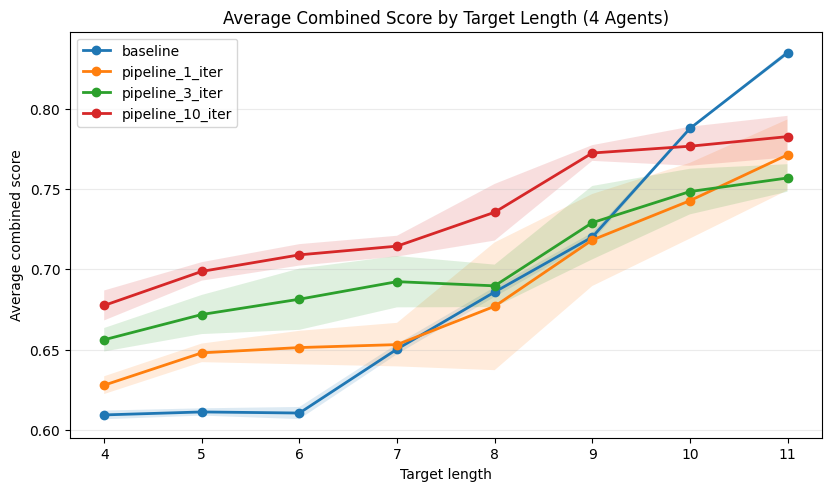

In [86]:
import matplotlib.pyplot as plt
import numpy as np

if "hardness_summary_df" not in globals() or hardness_summary_df.empty:
    print("Run the hard target-length experiment cell first to generate hardness_summary_df.")
else:
    plot_df = hardness_summary_df.copy()
    methods_order = ["baseline", "pipeline_1_iter", "pipeline_3_iter", "pipeline_10_iter"]

    target_lengths = sorted(plot_df["target_length"].unique(), reverse=True)
    x = np.array(target_lengths, dtype=float)

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)

    for method_name in methods_order:
        part = plot_df[plot_df["method"] == method_name].set_index("target_length")
        means = np.array([float(part.loc[t, "avg_score"]) if t in part.index else np.nan for t in target_lengths], dtype=float)
        errs = np.array(
            [
                float(part.loc[t, "std_score"]) if (t in part.index and pd.notna(part.loc[t, "std_score"])) else 0.0
                for t in target_lengths
            ],
            dtype=float,
        )

        ax.plot(x, means, marker="o", linewidth=2.0, label=method_name)
        ax.fill_between(x, means - errs, means + errs, alpha=0.15)

    ax.set_title("Average Combined Score by Target Length (4 Agents)")
    ax.set_xlabel("Target length")
    ax.set_ylabel("Average combined score")
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.show()

## Variety Study (Duplicates and Diversity)

This section now measures sequence variety for four agents under the same length-12 and length-5 protocol:
- Baseline
- Pipeline very-low-iteration (1 iteration)
- Pipeline low-iteration (3 iterations)
- Pipeline high-iteration (10 iterations)

Tracked metrics per run:
- Generated count
- Unique sequence count
- Duplicate count
- Duplicate rate = duplicates / generated

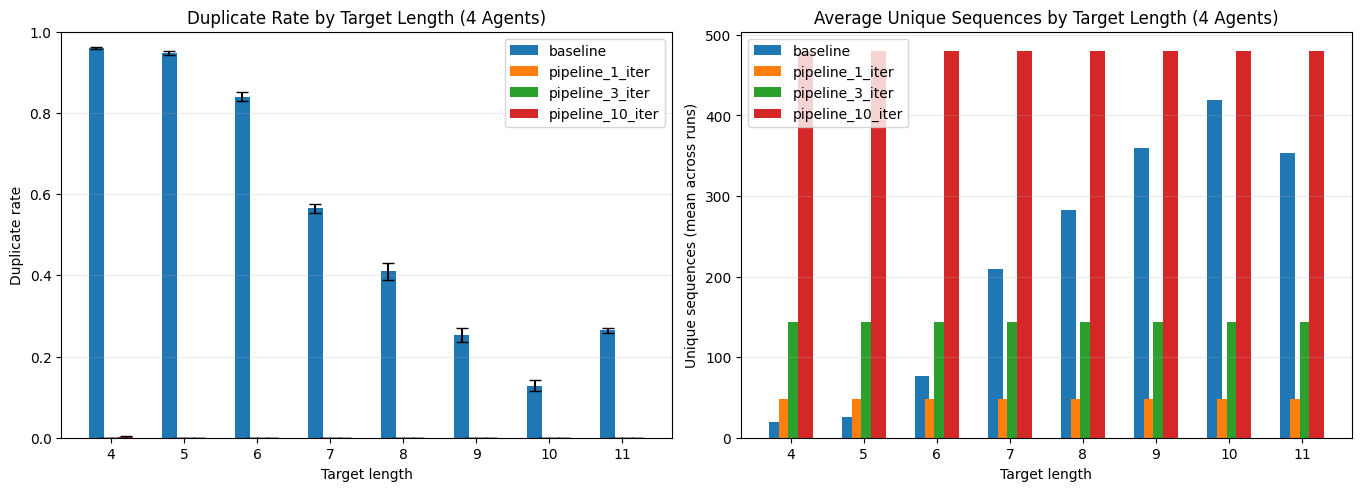

,target_length,method,requested_budget_mean,generated_mean,unique_mean,duplicate_mean,duplicate_rate_mean,duplicate_rate_std,topk_generated_mean,topk_unique_mean,topk_duplicate_mean,topk_duplicate_rate_mean,topk_duplicate_rate_std
0,11,baseline,480.0,480.0,353.2,126.8,0.264167,0.005187,480.0,353.2,126.8,0.264167,0.005187
1,11,pipeline_10_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
2,11,pipeline_1_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,4.0,4.0,0.0,0.000000,0.000000
3,11,pipeline_3_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,9.0,9.0,0.0,0.000000,0.000000
4,10,baseline,480.0,480.0,418.6,61.4,0.127917,0.013307,480.0,418.6,61.4,0.127917,0.013307
5,10,pipeline_10_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000
6,10,pipeline_1_iter,48.0,48.0,48.0,0.0,0.000000,0.000000,2.8,2.8,0.0,0.000000,0.000000
7,10,pipeline_3_iter,144.0,144.0,144.0,0.0,0.000000,0.000000,8.6,8.6,0.0,0.000000,0.000000
8,9,baseline,480.0,480.0,359.0,121.0,0.252083,0.017180,480.0,359.0,121.0,0.252083,0.017180
9,9,pipeline_10_iter,480.0,480.0,480.0,0.0,0.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000


In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "hardness_variety_summary_df" not in globals() or hardness_variety_summary_df.empty:
    print("Run the hard target-length experiment cell first to generate hardness_variety_summary_df.")
else:
    variety_plot_df = hardness_variety_summary_df.copy()
    methods_order = ["baseline", "pipeline_1_iter", "pipeline_3_iter", "pipeline_10_iter"]

    target_lengths = sorted(variety_plot_df["target_length"].unique())
    labels = [str(int(v)) for v in target_lengths]
    x = np.arange(len(labels))

    width = 0.20
    offsets = np.linspace(-width, width, len(methods_order))

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)

    for method_name, dx in zip(methods_order, offsets):
        part = variety_plot_df[variety_plot_df["method"] == method_name].set_index("target_length")

        dup_rate = np.array(
            [float(part.loc[t, "duplicate_rate_mean"]) if t in part.index else 0.0 for t in target_lengths],
            dtype=float,
        )
        dup_err = np.array(
            [
                float(part.loc[t, "duplicate_rate_std"])
                if (t in part.index and pd.notna(part.loc[t, "duplicate_rate_std"]))
                else 0.0
                for t in target_lengths
            ],
            dtype=float,
        )
        unique_vals = np.array(
            [float(part.loc[t, "unique_mean"]) if t in part.index else 0.0 for t in target_lengths],
            dtype=float,
        )

        axes[0].bar(
            x + dx,
            dup_rate,
            width,
            yerr=dup_err,
            capsize=4,
            label=method_name,
        )

        axes[1].bar(
            x + dx,
            unique_vals,
            width,
            label=method_name,
        )

    axes[0].set_title("Duplicate Rate by Target Length (4 Agents)")
    axes[0].set_xlabel("Target length")
    axes[0].set_ylabel("Duplicate rate")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    axes[1].set_title("Average Unique Sequences by Target Length (4 Agents)")
    axes[1].set_xlabel("Target length")
    axes[1].set_ylabel("Unique sequences (mean across runs)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend()

    plt.show()

    method_variety_df = (
        variety_plot_df[
            [
                "target_length",
                "method",
                "requested_budget_mean",
                "generated_mean",
                "unique_mean",
                "duplicate_mean",
                "duplicate_rate_mean",
                "duplicate_rate_std",
                "topk_generated_mean",
                "topk_unique_mean",
                "topk_duplicate_mean",
                "topk_duplicate_rate_mean",
                "topk_duplicate_rate_std",
            ]
        ]
        .sort_values(["target_length", "method"], ascending=[False, True])
        .reset_index(drop=True)
    )
    display(method_variety_df)

In [78]:
import gc
gc.collect()
if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()